Queremos entender se existe correção entre metricas extraidas do grafo e features linguisticas presentes no modelo.
> If the auxiliary classifier can predict a linguistic property well, then the original model likely encodes that property.

1- usar o probing sentence-level datasets/tasks created by Conneau et al. (2018), which are grouped into three categories. 

2- usar o SentEval toolkit

3 - replicar o experimento e procurar correlação entre as metricas de redes complexas e o classificador?

> Sim, a essência do processo é exatamente a mesma! Ambos os códigos têm o mesmo objetivo central: "abrir a caixa preta" do modelo de linguagem e extrair os vetores numéricos (as features ou hidden states) que ele gera enquanto lê o texto.

In [2]:
import pandas as pd
import csv
import os
import json

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from datasets import load_from_disk
from IPython.display import display
from datasets import Dataset, ClassLabel
from datetime import datetime

from llm_mri import ActivationAreas, Evaluation
from llm_mri.dimensionality_reduction import PCA, UMAP, SVD

# Save Graph

In [2]:
# Constants
GRID_SIZES = [10, 20, 30, 40, 50]
SAMPLE_SIZE = 1000

# Paths
fakenews_data_path = "../data/fakenews"
processed_graphs_path = f"{fakenews_data_path}/processed/graphs"

In [5]:
model_ckpt = "distilbert/distilbert-base-multilingual-cased"
# The model can also be an encoder, such as 'openai-community/gpt2'

# Correct dataset path (note: folder is `datasets`, not `dataset`)
dataset_path = '../datasets/dataset_encoded.hf'

# Load the dataset using Hugging Face's `load_dataset` function
dataset = load_from_disk(dataset_path)
dataset.cleanup_cache_files()

10

In [21]:
umap = UMAP(n_components=2, random_state=42, gridsize=10)
llm_mri = ActivationAreas(
    model=model_ckpt, device="cpu", dataset=dataset, reduction_method=umap
)
llm_mri.process_activation_areas(
  # save_raw_path="data/dados_hf_brutos",
  # save_reduced_path="data/reduzidos.pt",
  save_jsonl_path="data/features.json"
)

g_true = llm_mri.get_graph("true")
g_fake = llm_mri.get_graph("fake")
g_total = llm_mri.get_graph("fake", "true")

print(g_true.graph)
print(g_fake.graph)


Map:   0%|          | 0/40 [00:00<?, ? examples/s]

Exporting features in extract_features format to: data/features_extratas.json...
JSONL file saved successfully!


/home/f-msc2026/ra256352/Documents/pos/code/master_degree_lab/venv/lib64/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/f-msc2026/ra256352/Documents/pos/code/master_degree_lab/venv/lib64/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/f-msc2026/ra256352/Documents/pos/code/master_degree_lab/venv/lib64/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/f-msc2026/ra256352/Documents/pos/code/master_degree_lab/venv/lib64/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/f-msc2026/ra256352/Documents/pos/code/master_degree_lab/venv/lib64/python3.13/site-packages/umap/u

{'label_names': ['true'], 'layers': 7}
{'label_names': ['fake'], 'layers': 7}


In [10]:
# Save data
nx.write_gexf(g_true, f"data/g_true.gexf")
nx.write_gexf(g_fake, f"data/g_fake.gexf")
nx.write_gexf(g_total, f"data/g_total.gexf")

# Save Layers Metrics

In [17]:
existent_labels = ["true", "fake", "total"]

In [11]:
def get_layer_number(node_name):
    return int(node_name.split("_")[0])

def get_edge_name(source, target):
    source_layer = get_layer_number(source)
    target_layer = get_layer_number(target)
    
    if source_layer < target_layer:
        return f"{source_layer}>>{target_layer}"
    return f"{target_layer}>>{source_layer}"

def merge_data_from_dicts(d1, d2):
    all_keys = d1.keys() | d2.keys()

    d2_value_type = type(list(d2.values())[0])
    if d2_value_type is list:
        return {k: [*d1.get(k, []), *d2.get(k, [])] for k in all_keys}
    
    return {k: [*d1.get(k, []), d2.get(k, 0)] for k in all_keys}


def get_degree_per_layer(graph):
    degree_per_layer = dict()
    current_graph_degree = graph.degree()
    for node, degree in current_graph_degree:
        layer = get_layer_number(node)
        if layer in degree_per_layer:
            degree_per_layer[layer].append(degree)
        else:
            degree_per_layer[layer] = [degree]
    return degree_per_layer

def get_num_nodes_per_layer(graph):
    nodes_per_layer = dict()
    for node in graph.nodes():
        layer = get_layer_number(node)
        if layer in nodes_per_layer:
            nodes_per_layer[layer] += 1
        else:
            nodes_per_layer[layer] = 1
    return nodes_per_layer

def get_num_edges_per_layer(graph):
    edges_per_layer = dict()
    for source, target in graph.edges():
        edge_name = get_edge_name(source, target)
        if edge_name in edges_per_layer:
            edges_per_layer[edge_name] += 1
        else:
            edges_per_layer[edge_name] = 1
    return edges_per_layer

def get_metric_function(metric_name=None):
    metric_name_dict = {
        "degree_per_layer": get_degree_per_layer,
        "num_nodes_per_layer": get_num_nodes_per_layer,
        "num_edges_per_layer": get_num_edges_per_layer,
    }
    if metric_name is None:
        return metric_name_dict
    return metric_name_dict.get(metric_name)
    

In [22]:
import pandas as pd
import os
import json
import numpy as np
import networkx as nx

# Limpa o arquivo existente
metrics_per_layers_path = f"data/metrics_per_layers.json"
csv_output_path = f"data/metrics_per_layers.csv"

if os.path.exists(metrics_per_layers_path):
    os.remove(metrics_per_layers_path)
with open(metrics_per_layers_path, "w") as f:
    pass

final_metrics = dict()
# Lista para armazenar os dados do DataFrame
rows_list = []

GRID_SIZES = [10]
for grid_size in GRID_SIZES:
    final_metrics[grid_size] = dict()
    
    for label_type in existent_labels:
        final_metrics[grid_size][label_type] = dict()

        for metric_name, metric_func in get_metric_function().items():
            general_metric_per_layer = dict()
            
            for sample in range(10):
                current_graph = nx.read_gexf(f"data/g_{label_type}.gexf")
                current_metric_per_layer = metric_func(current_graph)
                general_metric_per_layer = merge_data_from_dicts(
                    general_metric_per_layer, current_metric_per_layer
                )

            # Processamento por camada
            for layer, metrics in general_metric_per_layer.items():
                mean_val = np.mean(metrics)
                stderr_val = np.std(metrics) / np.sqrt(len(metrics))

                # 1. Salva no dicionário original (JSON)
                if metric_name not in final_metrics[grid_size][label_type]:
                    final_metrics[grid_size][label_type][metric_name] = {}
                
                final_metrics[grid_size][label_type][metric_name][layer] = {
                    "mean": mean_val,
                    "stderr": stderr_val,
                }

                # 2. Adiciona à lista do Pandas
                rows_list.append({
                    "grid_size": grid_size,
                    "label_type": label_type,
                    "metric": metric_name,
                    "layer": layer,
                    "mean": mean_val,
                    "stderr": stderr_val
                })

# --- Salvando os resultados ---

# Salva JSON
with open(metrics_per_layers_path, "w") as f:
    json.dump(final_metrics, f)

# Cria e salva o DataFrame
df_metrics = pd.DataFrame(rows_list)
df_metrics.to_csv(csv_output_path, index=False)

# Exibe o topo do dataframe para conferência
print(df_metrics.head())

   grid_size label_type            metric layer      mean    stderr
0         10       true  degree_per_layer     0  1.000000  0.000000
1         10       true  degree_per_layer     1  2.222222  0.046849
2         10       true  degree_per_layer     2  2.105263  0.032399
3         10       true  degree_per_layer     3  2.222222  0.046849
4         10       true  degree_per_layer     4  3.777778  0.209513


## Plot results by layer

In [13]:
# Load metrics per layers data
with open(metrics_per_layers_path, "r") as f:
    metrics_per_layers_data = json.load(f)

print("Dados carregados com sucesso!")
print(f"Grid sizes disponíveis: {list(metrics_per_layers_data.keys())}")
print(f"Métricas disponíveis: {list(metrics_per_layers_data['10']['true'].keys())}")


Dados carregados com sucesso!
Grid sizes disponíveis: ['10']
Métricas disponíveis: ['degree_per_layer', 'num_nodes_per_layer', 'num_edges_per_layer']


In [18]:
def plot_layer_evolution(data, grid_size, metric_name, ylabel=None):
    """
    Plot the evolution of a metric across layers for a specific grid size.
    Shows two lines: one for 'true' and one for 'fake' labels.
    
    Args:
        data: Data loaded from metrics_per_layers.json
        grid_size: Grid size to plot
        metric_name: Name of the metric to plot ('degree_per_layer', 'num_nodes_per_layer', 'num_edges_per_layer')
        ylabel: Label for y-axis (if None, uses metric_name)
    """
    plt.figure(figsize=(12, 6))
    
    # Define colors for each label type
    colors = {
        "true": "#3498db",
        "fake": "#e74c3c",
        "total": "#2ecc71"
    }
    
    # Define line styles
    linestyles = {
        "true": "-",
        "fake": "--",
        "total": "-."
    }
    
    # Iterate over label types (true and fake)
    for label_type in existent_labels:
        metric_data = data[grid_size][label_type][metric_name]
        
        # Extract layers, means, and standard errors
        # For num_edges_per_layer, the keys are like "0>>1", "1>>2", etc.
        # For degree_per_layer and num_nodes_per_layer, keys are layer numbers
        
        # Sort layers appropriately
        if metric_name == "num_edges_per_layer":
            # For edges, sort by first layer number
            sorted_layers = sorted(metric_data.keys(), key=lambda x: int(x.split(">>")[0]))
        else:
            # For nodes and degree, sort numerically
            sorted_layers = sorted(metric_data.keys(), key=lambda x: int(x))
        
        means = [metric_data[layer]["mean"] for layer in sorted_layers]
        stderrs = [metric_data[layer]["stderr"] for layer in sorted_layers]
        
        # Plot with error bars
        plt.errorbar(
            sorted_layers,
            means,
            yerr=stderrs,
            label=f"{label_type.capitalize()}",
            capsize=5,
            color=colors[label_type],
            linestyle=linestyles[label_type],
            linewidth=2.5,
            marker='o',
            markersize=6,
            alpha=0.8
        )
    
    # Set labels and title
    if ylabel is None:
        ylabel = metric_name
    
    plt.title(f"Evolution of {ylabel} Across Layers (Grid Size: {grid_size})", fontsize=14, fontweight='bold')
    plt.xlabel("Layers", fontweight='bold', fontsize=11)
    plt.ylabel(ylabel, fontweight='bold', fontsize=11)
    plt.legend(fontsize=11, loc='best')
    plt.grid(alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()



Grid Size: 10
Plotting degree_per_layer...


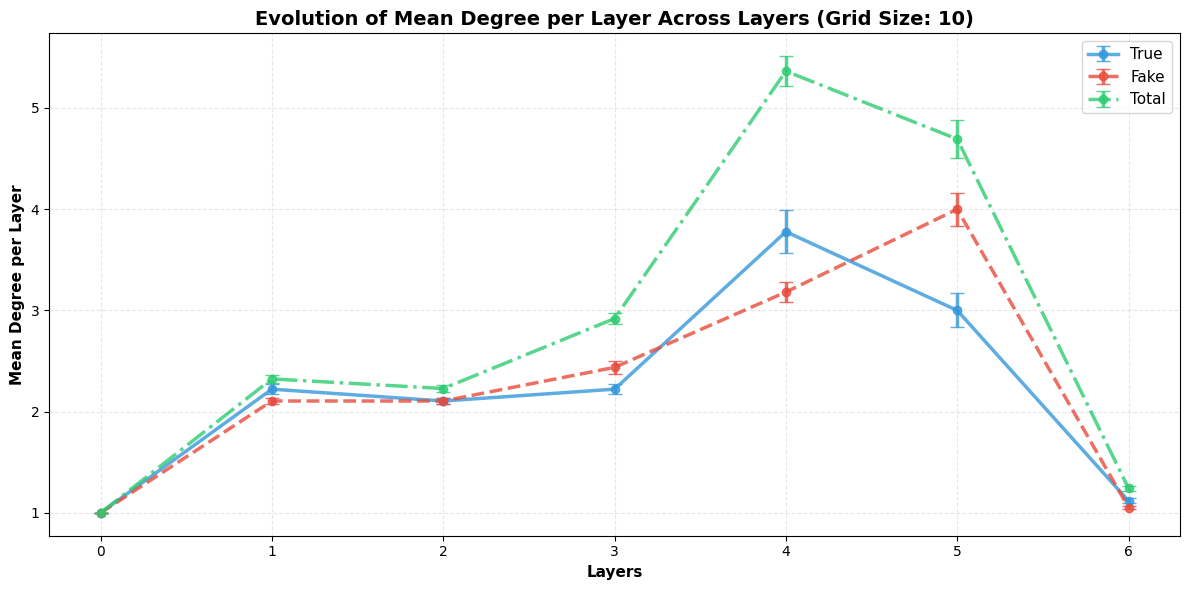

Plotting num_nodes_per_layer...


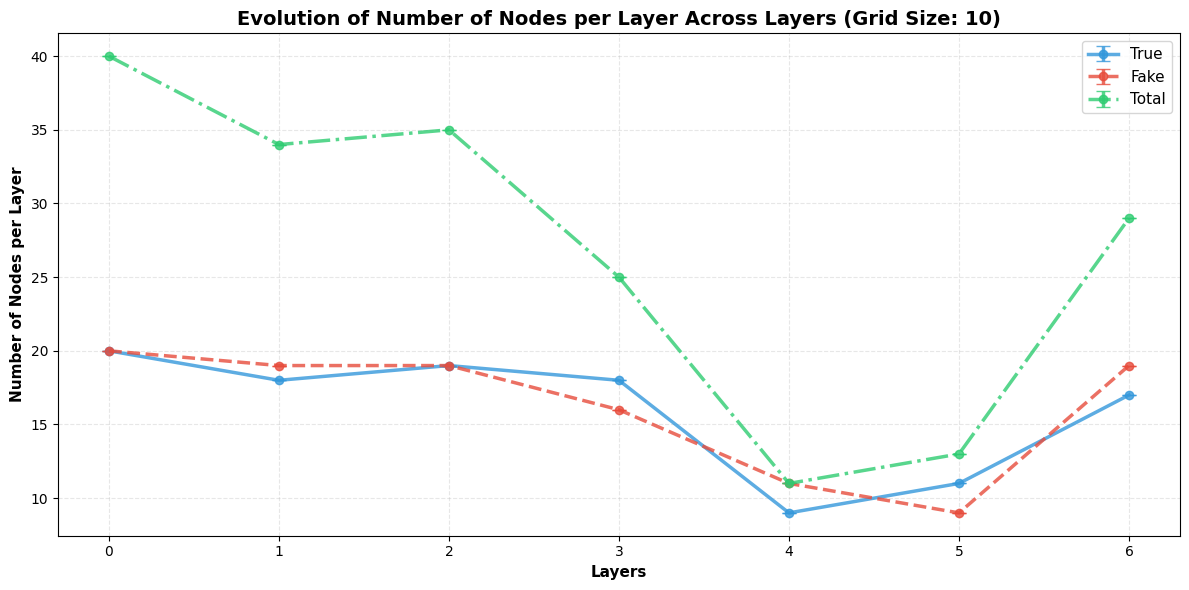

Plotting num_edges_per_layer...


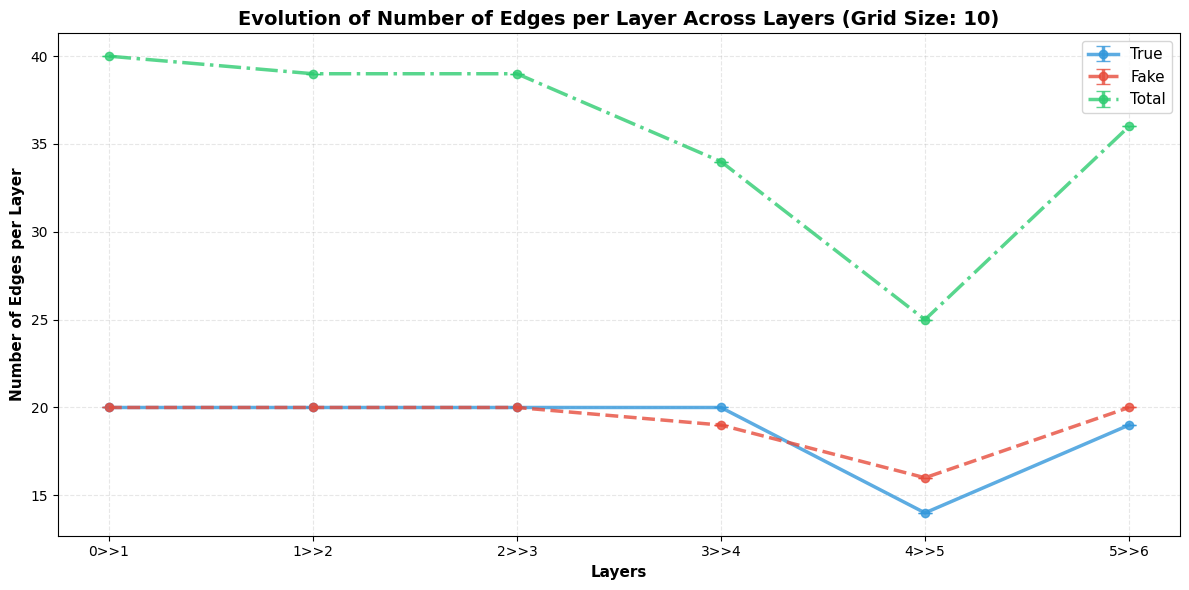

In [20]:
# Define metric display names
metric_labels = {
    "degree_per_layer": "Mean Degree per Layer",
    "num_nodes_per_layer": "Number of Nodes per Layer",
    "num_edges_per_layer": "Number of Edges per Layer"
}

# Plot for each grid size and each metric
for grid_size in GRID_SIZES:
    print(f"\n{'='*60}")
    print(f"Grid Size: {grid_size}")
    print(f"{'='*60}")
    
    
    # for metric_name in ["num_nodes_per_layer"]:
    for metric_name in get_metric_function().keys():
        print(f"Plotting {metric_name}...")
        ylabel = metric_labels.get(metric_name, metric_name)
        plot_layer_evolution(metrics_per_layers_data, str(grid_size), metric_name, ylabel)

# Probing Tasks - Fake News Classifier

Nesta seção, implementamos um classificador simples (probing classifier) para verificar se as features extraídas por cada camada do BERT contêm informação útil para distinguir entre notícias verdadeiras e falsas.

> "If the auxiliary classifier can predict a linguistic property well, then the original model likely encodes that property." - Conneau et al., 2018

Vamos treinar um MLP simples para cada camada e comparar a acurácia, revelando qual camada melhor codifica a distinção fake vs. true.

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns
from tqdm.auto import tqdm

# Set random seed for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [4]:
def load_probing_data(features_path, true_folder, fake_folder):
    """
    Load features and labels for the probing task.
    
    Args:
        features_path: Path to features.json file
        true_folder: Path to folder with true news texts
        fake_folder: Path to folder with fake news texts
        
    Returns:
        features_by_layer: Dict mapping layer index to list of features
        labels: List of labels (0=fake, 1=true)
        texts: List of original texts
    """
    # Load features
    with open(features_path, 'r') as f:
        features_data = [json.loads(line) for line in f]
    
    # Get list of text files
    true_files = sorted([f for f in os.listdir(true_folder) if f.endswith('.txt')])
    fake_files = sorted([f for f in os.listdir(fake_folder) if f.endswith('.txt')])
    
    # Initialize storage
    features_by_layer = {i: [] for i in range(7)}  # DistilBERT has 7 layers (0-6)
    labels = []
    texts = []
    
    # Process true news (label = 1)
    for idx, filename in enumerate(true_files):
        if idx < len(features_data):
            # Extract [CLS] token features from each layer
            for layer_data in features_data[idx]['features'][0]['layers']:
                layer_idx = layer_data['index']
                features_by_layer[layer_idx].append(layer_data['values'])
            
            labels.append(1)
            
            # Read text
            with open(os.path.join(true_folder, filename), 'r') as f:
                texts.append(f.read().strip())
    
    # Process fake news (label = 0)
    start_idx = len(true_files)
    for idx, filename in enumerate(fake_files):
        feat_idx = start_idx + idx
        if feat_idx < len(features_data):
            # Extract [CLS] token features from each layer
            for layer_data in features_data[feat_idx]['features'][0]['layers']:
                layer_idx = layer_data['index']
                features_by_layer[layer_idx].append(layer_data['values'])
            
            labels.append(0)
            
            # Read text
            with open(os.path.join(fake_folder, filename), 'r') as f:
                texts.append(f.read().strip())
    
    return features_by_layer, labels, texts

# Load data
features_path = 'data/features.json'
true_folder = '../datasets/true'
fake_folder = '../datasets/fake'

features_by_layer, labels, texts = load_probing_data(features_path, true_folder, fake_folder)

print(f"Loaded {len(labels)} samples")
print(f"True news: {sum(labels)} samples")
print(f"Fake news: {len(labels) - sum(labels)} samples")
print(f"Number of layers: {len(features_by_layer)}")
print(f"Feature dimension: {len(features_by_layer[0][0])}")

Loaded 40 samples
True news: 20 samples
Fake news: 20 samples
Number of layers: 7
Feature dimension: 768


In [5]:
class ProbingDataset(Dataset):
    """PyTorch Dataset for probing task."""
    
    def __init__(self, features, labels):
        """
        Args:
            features: List or array of feature vectors
            labels: List or array of labels
        """
        self.features = torch.FloatTensor(features)
        self.labels = torch.LongTensor(labels)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

def create_dataloaders(features, labels, train_ratio=0.7, val_ratio=0.15, batch_size=16):
    """
    Create train, validation, and test dataloaders.
    
    Args:
        features: Feature vectors
        labels: Labels
        train_ratio: Proportion of data for training
        val_ratio: Proportion of data for validation
        batch_size: Batch size for dataloaders
        
    Returns:
        train_loader, val_loader, test_loader
    """
    dataset = ProbingDataset(features, labels)
    
    # Calculate split sizes
    total_size = len(dataset)
    train_size = int(train_ratio * total_size)
    val_size = int(val_ratio * total_size)
    test_size = total_size - train_size - val_size
    
    # Split dataset
    train_dataset, val_dataset, test_dataset = random_split(
        dataset, 
        [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(SEED)
    )
    
    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader

print("Dataset class created successfully!")

Dataset class created successfully!


In [6]:
class MLPProbe(nn.Module):
    """
    Simple MLP for probing task.
    
    Architecture:
    - Input layer
    - Hidden layer with ReLU activation and Dropout
    - Output layer (binary classification)
    """
    
    def __init__(self, input_dim, hidden_dim=128, dropout=0.3):
        """
        Args:
            input_dim: Dimension of input features
            hidden_dim: Dimension of hidden layer
            dropout: Dropout probability
        """
        super(MLPProbe, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 2)  # Binary classification
        )
    
    def forward(self, x):
        return self.network(x)

# Test model instantiation
input_dim = len(features_by_layer[0][0])
test_model = MLPProbe(input_dim)
print(f"Model architecture:\n{test_model}")
print(f"\nTotal parameters: {sum(p.numel() for p in test_model.parameters()):,}")

Model architecture:
MLPProbe(
  (network): Sequential(
    (0): Linear(in_features=768, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=2, bias=True)
  )
)

Total parameters: 98,690


In [7]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    for features, labels in dataloader:
        features, labels = features.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Track metrics
        total_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    
    return avg_loss, accuracy

def evaluate(model, dataloader, criterion, device):
    """Evaluate the model."""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for features, labels in dataloader:
            features, labels = features.to(device), labels.to(device)
            
            outputs = model(features)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='binary', zero_division=0
    )
    
    return avg_loss, accuracy, precision, recall, f1, all_preds, all_labels

print("Training and evaluation functions defined!")

Training and evaluation functions defined!


In [9]:
def train_probe_for_layer(layer_idx, features, labels, hidden_dim=128, 
                          num_epochs=50, lr=0.001, batch_size=16, 
                          patience=10, verbose=False):
    """
    Train a probing classifier for a specific layer.
    
    Args:
        layer_idx: Index of the layer
        features: Feature vectors for this layer
        labels: Labels
        hidden_dim: Hidden dimension for MLP
        num_epochs: Maximum number of epochs
        lr: Learning rate
        batch_size: Batch size
        patience: Early stopping patience
        verbose: Whether to print training progress
        
    Returns:
        results: Dictionary with test metrics and model
    """
    # Create dataloaders
    train_loader, val_loader, test_loader = create_dataloaders(
        features, labels, batch_size=batch_size
    )
    
    # Initialize model
    input_dim = len(features[0])
    model = MLPProbe(input_dim, hidden_dim).to(device)
    
    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    
    # Training loop with early stopping
    best_val_acc = 0
    patience_counter = 0
    
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _, _, _, _ = evaluate(model, val_loader, criterion, device)
        
        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} - "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
                  f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
        
        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch+1}")
                break
    
    # Load best model and evaluate on test set
    model.load_state_dict(best_model_state)
    test_loss, test_acc, test_prec, test_rec, test_f1, preds, true_labels = evaluate(
        model, test_loader, criterion, device
    )
    
    results = {
        'layer': layer_idx,
        'test_accuracy': test_acc,
        'test_precision': test_prec,
        'test_recall': test_rec,
        'test_f1': test_f1,
        'best_val_accuracy': best_val_acc,
        'model': model,
        'predictions': preds,
        'true_labels': true_labels
    }
    
    return results

print("Ready to train probing classifiers!")

Ready to train probing classifiers!


In [10]:
# Train probing classifier for each layer
print("Training probing classifiers for each layer...\n")

layer_results = []

for layer_idx in tqdm(range(7), desc="Training layers"):
    print(f"\n{'='*60}")
    print(f"Training classifier for Layer {layer_idx}")
    print(f"{'='*60}")
    
    results = train_probe_for_layer(
        layer_idx=layer_idx,
        features=features_by_layer[layer_idx],
        labels=labels,
        hidden_dim=128,
        num_epochs=100,
        lr=0.001,
        batch_size=16,
        patience=15,
        verbose=True
    )
    
    layer_results.append(results)
    
    print(f"\n📊 Results for Layer {layer_idx}:")
    print(f"  Test Accuracy:  {results['test_accuracy']:.4f}")
    print(f"  Test Precision: {results['test_precision']:.4f}")
    print(f"  Test Recall:    {results['test_recall']:.4f}")
    print(f"  Test F1:        {results['test_f1']:.4f}")

print("\n✅ All layers trained!")

Training probing classifiers for each layer...



Training layers:   0%|          | 0/7 [00:00<?, ?it/s]


Training classifier for Layer 0
Epoch 10/100 - Train Loss: 0.6873, Train Acc: 0.6071, Val Loss: 0.7864, Val Acc: 0.1667
Early stopping at epoch 16

📊 Results for Layer 0:
  Test Accuracy:  0.3333
  Test Precision: 0.3333
  Test Recall:    1.0000
  Test F1:        0.5000

Training classifier for Layer 1
Epoch 10/100 - Train Loss: 0.6703, Train Acc: 0.6071, Val Loss: 0.8591, Val Acc: 0.1667
Early stopping at epoch 16

📊 Results for Layer 1:
  Test Accuracy:  0.3333
  Test Precision: 0.3333
  Test Recall:    1.0000
  Test F1:        0.5000

Training classifier for Layer 2
Epoch 10/100 - Train Loss: 0.6560, Train Acc: 0.6429, Val Loss: 0.8331, Val Acc: 0.1667
Early stopping at epoch 16

📊 Results for Layer 2:
  Test Accuracy:  0.3333
  Test Precision: 0.3333
  Test Recall:    1.0000
  Test F1:        0.5000

Training classifier for Layer 3
Epoch 10/100 - Train Loss: 0.5081, Train Acc: 0.8214, Val Loss: 0.7400, Val Acc: 0.5000
Epoch 20/100 - Train Loss: 0.4145, Train Acc: 0.8214, Val Loss:

In [11]:
# Create summary DataFrame
results_df = pd.DataFrame([
    {
        'Layer': r['layer'],
        'Accuracy': r['test_accuracy'],
        'Precision': r['test_precision'],
        'Recall': r['test_recall'],
        'F1 Score': r['test_f1']
    }
    for r in layer_results
])

print("\n📈 Summary of Results:")
print(results_df.to_string(index=False))
print(f"\n🏆 Best performing layer: Layer {results_df.loc[results_df['Accuracy'].idxmax(), 'Layer']:.0f}")
print(f"   with accuracy: {results_df['Accuracy'].max():.4f}")

# Save results to CSV
csv_output_path = "data/probing_results.csv"
results_df.to_csv(csv_output_path, index=False)
print(f"\n💾 Results saved to: {csv_output_path}")


📈 Summary of Results:
 Layer  Accuracy  Precision  Recall  F1 Score
     0  0.333333   0.333333     1.0       0.5
     1  0.333333   0.333333     1.0       0.5
     2  0.333333   0.333333     1.0       0.5
     3  1.000000   1.000000     1.0       1.0
     4  1.000000   1.000000     1.0       1.0
     5  0.833333   0.666667     1.0       0.8
     6  0.833333   0.666667     1.0       0.8

🏆 Best performing layer: Layer 3
   with accuracy: 1.0000

💾 Results saved to: data/probing_results.csv


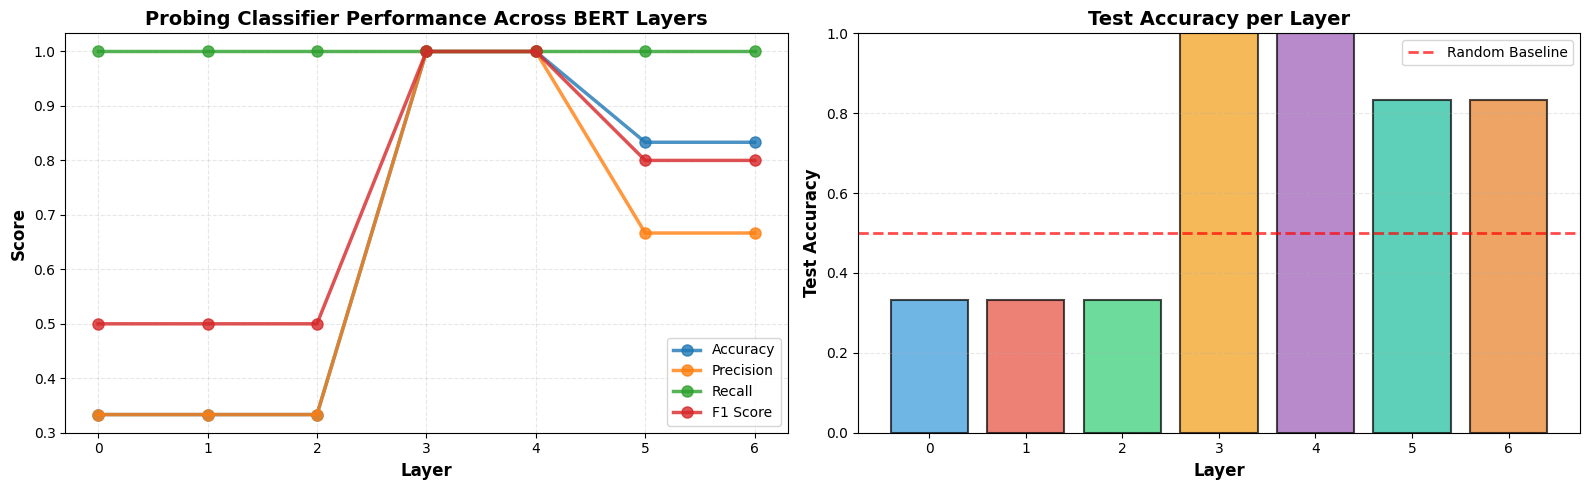

In [12]:
# Plot accuracy across layers
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: All metrics
ax1 = axes[0]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
for metric in metrics:
    ax1.plot(results_df['Layer'], results_df[metric], 
             marker='o', linewidth=2.5, markersize=8, label=metric, alpha=0.8)

ax1.set_xlabel('Layer', fontsize=12, fontweight='bold')
ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
ax1.set_title('Probing Classifier Performance Across BERT Layers', 
              fontsize=14, fontweight='bold')
ax1.legend(fontsize=10, loc='best')
ax1.grid(alpha=0.3, linestyle='--')
ax1.set_xticks(range(7))

# Plot 2: Accuracy with error bars (showing variance)
ax2 = axes[1]
ax2.bar(results_df['Layer'], results_df['Accuracy'], 
        color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22'],
        alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='Random Baseline', alpha=0.7)
ax2.set_xlabel('Layer', fontsize=12, fontweight='bold')
ax2.set_ylabel('Test Accuracy', fontsize=12, fontweight='bold')
ax2.set_title('Test Accuracy per Layer', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_xticks(range(7))
ax2.set_ylim([0, 1])

plt.tight_layout()
plt.show()

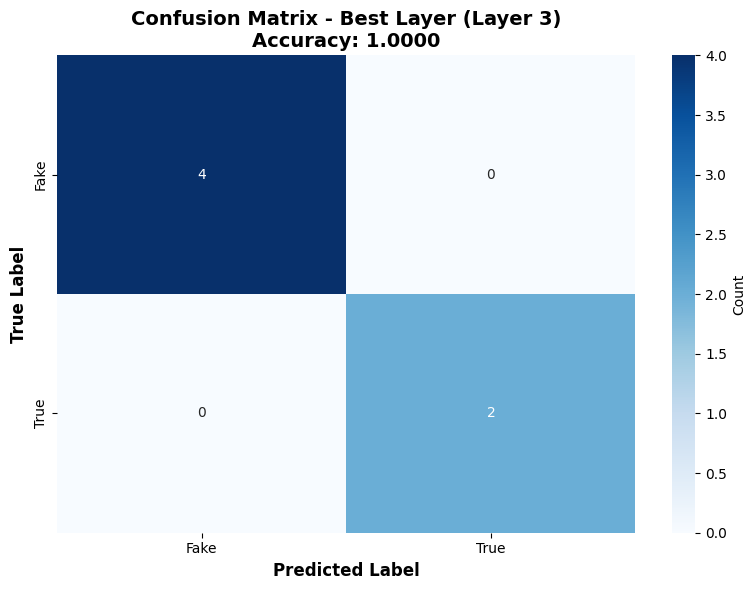

In [13]:
# Plot confusion matrix for the best layer
best_layer_idx = results_df.loc[results_df['Accuracy'].idxmax(), 'Layer'].astype(int)
best_result = layer_results[best_layer_idx]

cm = confusion_matrix(best_result['true_labels'], best_result['predictions'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Fake', 'True'], 
            yticklabels=['Fake', 'True'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title(f'Confusion Matrix - Best Layer (Layer {best_layer_idx})\nAccuracy: {best_result["test_accuracy"]:.4f}', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
print("="*70)
print("ANÁLISE DOS RESULTADOS - PROBING CLASSIFIER")
print("="*70)

# Find best and worst layers
best_idx = results_df['Accuracy'].idxmax()
worst_idx = results_df['Accuracy'].idxmin()

print(f"\n🏆 MELHOR CAMADA: Layer {results_df.loc[best_idx, 'Layer']:.0f}")
print(f"   Acurácia: {results_df.loc[best_idx, 'Accuracy']:.4f}")
print(f"   F1-Score: {results_df.loc[best_idx, 'F1 Score']:.4f}")

print(f"\n📉 PIOR CAMADA: Layer {results_df.loc[worst_idx, 'Layer']:.0f}")
print(f"   Acurácia: {results_df.loc[worst_idx, 'Accuracy']:.4f}")
print(f"   F1-Score: {results_df.loc[worst_idx, 'F1 Score']:.4f}")

print(f"\n📊 ESTATÍSTICAS GERAIS:")
print(f"   Acurácia média: {results_df['Accuracy'].mean():.4f} ± {results_df['Accuracy'].std():.4f}")
print(f"   Melhor desempenho vs Random: +{(results_df['Accuracy'].max() - 0.5)*100:.2f}%")

print("\n💡 INTERPRETAÇÃO:")
if results_df.loc[best_idx, 'Layer'] <= 2:
    print("   As camadas iniciais capturam melhor a distinção fake vs. true,")
    print("   sugerindo que features sintáticas/superficiais são relevantes.")
elif results_df.loc[best_idx, 'Layer'] >= 4:
    print("   As camadas finais capturam melhor a distinção fake vs. true,")
    print("   sugerindo que features semânticas de alto nível são mais relevantes.")
else:
    print("   As camadas intermediárias capturam melhor a distinção fake vs. true,")
    print("   sugerindo um equilíbrio entre features sintáticas e semânticas.")

print("\n" + "="*70)

ANÁLISE DOS RESULTADOS - PROBING CLASSIFIER

🏆 MELHOR CAMADA: Layer 3
   Acurácia: 1.0000
   F1-Score: 1.0000

📉 PIOR CAMADA: Layer 0
   Acurácia: 0.3333
   F1-Score: 0.5000

📊 ESTATÍSTICAS GERAIS:
   Acurácia média: 0.6667 ± 0.3191
   Melhor desempenho vs Random: +50.00%

💡 INTERPRETAÇÃO:
   As camadas intermediárias capturam melhor a distinção fake vs. true,
   sugerindo um equilíbrio entre features sintáticas e semânticas.



# Correlation

In [15]:
# Load datasets
probing_df = pd.read_csv("data/probing_results.csv")
metrics_df = pd.read_csv("data/metrics_per_layers.csv")

print("Probing Results Dataset:")
display(probing_df.head())
print("\nMetrics per Layers Dataset:")
display(metrics_df.head(10))

Probing Results Dataset:


,Layer,Accuracy,Precision,Recall,F1 Score
0,0,0.333333,0.333333,1.0,0.5
1,1,0.333333,0.333333,1.0,0.5
2,2,0.333333,0.333333,1.0,0.5
3,3,1.000000,1.000000,1.0,1.0
4,4,1.000000,1.000000,1.0,1.0



Metrics per Layers Dataset:


,grid_size,label_type,metric,layer,mean,stderr
0,10,true,degree_per_layer,0,1.000000,0.000000
1,10,true,degree_per_layer,1,2.222222,0.046849
2,10,true,degree_per_layer,2,2.105263,0.032399
3,10,true,degree_per_layer,3,2.222222,0.046849
4,10,true,degree_per_layer,4,3.777778,0.209513
5,10,true,degree_per_layer,5,3.000000,0.167628
6,10,true,degree_per_layer,6,1.117647,0.024711
7,10,true,num_nodes_per_layer,0,20.000000,0.000000
8,10,true,num_nodes_per_layer,1,18.000000,0.000000
9,10,true,num_nodes_per_layer,2,19.000000,0.000000


In [16]:
# Pivot metrics_df to have one row per layer with metrics as columns
# Filter for total label_type to get overall metrics
metrics_pivot = metrics_df[metrics_df['label_type'] == 'total'].copy()

# Create a pivot table with metrics and layers
metrics_wide = metrics_pivot.pivot_table(
    index='layer',
    columns='metric',
    values='mean',
    aggfunc='first'
).reset_index()

# Rename layer to Layer to match probing_df
metrics_wide.rename(columns={'layer': 'Layer'}, inplace=True)

print("Pivoted Metrics Dataset:")
display(metrics_wide)

Pivoted Metrics Dataset:


metric,Layer,degree_per_layer,num_edges_per_layer,num_nodes_per_layer
0,0,1.000000,NaN,40.0
1,0>>1,NaN,40.0,NaN
2,1,2.323529,NaN,34.0
3,1>>2,NaN,39.0,NaN
4,2,2.228571,NaN,35.0
5,2>>3,NaN,39.0,NaN
6,3,2.920000,NaN,25.0
7,3>>4,NaN,34.0,NaN
8,4,5.363636,NaN,11.0
9,4>>5,NaN,25.0,NaN


In [17]:
# Merge the two datasets on Layer
merged_df = pd.merge(probing_df, metrics_wide, on='Layer', how='inner')

print("Merged Dataset:")
display(merged_df)
print(f"\nShape: {merged_df.shape}")
print(f"Columns: {list(merged_df.columns)}")

ValueError: You are trying to merge on int64 and object columns for key 'Layer'. If you wish to proceed you should use pd.concat

In [ ]:
# Calculate correlation matrix for numerical columns only
# Exclude Layer as it's just an index
numerical_cols = merged_df.select_dtypes(include=[np.number]).columns.tolist()
if 'Layer' in numerical_cols:
    numerical_cols.remove('Layer')

correlation_matrix = merged_df[numerical_cols].corr()

print("Correlation Matrix:")
display(correlation_matrix)

In [ ]:
# Visualize correlation matrix with heatmap
import seaborn as sns

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={'label': 'Correlation Coefficient'},
            linewidths=0.5, linecolor='gray')
plt.title('Correlation Matrix: Probing Metrics vs Network Metrics', 
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Find strongest correlations with probing metrics
probing_metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
network_metrics = [col for col in numerical_cols if col not in probing_metrics]

print("="*80)
print("STRONGEST CORRELATIONS BETWEEN PROBING AND NETWORK METRICS")
print("="*80)

for probing_metric in probing_metrics:
    if probing_metric in correlation_matrix.columns:
        print(f"\n🔍 {probing_metric}:")
        correlations = correlation_matrix[probing_metric][network_metrics].sort_values(ascending=False)
        
        print("\n   Top Positive Correlations:")
        for metric, corr in correlations.head(3).items():
            print(f"   • {metric}: {corr:.4f}")
        
        print("\n   Top Negative Correlations:")
        for metric, corr in correlations.tail(3).items():
            print(f"   • {metric}: {corr:.4f}")

print("\n" + "="*80)

In [ ]:
# Scatter plots for strongest correlations
# Find the strongest correlation with Accuracy
if 'Accuracy' in correlation_matrix.columns:
    acc_corrs = correlation_matrix['Accuracy'][network_metrics].abs().sort_values(ascending=False)
    top_3_metrics = acc_corrs.head(3).index.tolist()
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for idx, metric in enumerate(top_3_metrics):
        ax = axes[idx]
        ax.scatter(merged_df[metric], merged_df['Accuracy'], 
                  s=100, alpha=0.6, c=merged_df['Layer'], cmap='viridis')
        
        # Add trend line
        z = np.polyfit(merged_df[metric], merged_df['Accuracy'], 1)
        p = np.poly1d(z)
        ax.plot(merged_df[metric], p(merged_df[metric]), 
               "r--", alpha=0.8, linewidth=2, label=f'Trend line')
        
        # Add correlation coefficient
        corr = correlation_matrix.loc['Accuracy', metric]
        ax.text(0.05, 0.95, f'r = {corr:.3f}', 
               transform=ax.transAxes, fontsize=12, 
               verticalalignment='top', fontweight='bold',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        ax.set_xlabel(metric, fontsize=11, fontweight='bold')
        ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
        ax.set_title(f'Accuracy vs {metric}', fontsize=12, fontweight='bold')
        ax.grid(alpha=0.3, linestyle='--')
        ax.legend()
    
    plt.tight_layout()
    plt.show()